In [ ]:
# Plot style
import matplotlib as mpl
mpl.rcParams["font.family"] = "CMU Serif"


# Love–C Relation Test (Using Precomputed H00 Grid)

This notebook loads the H00 grid generated by `solver_h00.py`, computes the Love–C relation, and compares numerical vs analytic solutions for `h00` and `u = h00/r^2`.

No TOV or H00 integration is performed here.

In [1]:
import os
import pickle
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import sys
from pathlib import Path


# Add parent directory to path to import helper functions
sys.path.append(str(Path.cwd().parent))

from h00_aux import h00_approx, h00p_approx
from solver_tov import cgs_to_geom

plt.rcParams["mathtext.fontset"] = "cm"

In [2]:
# Load config to get h/eps/K_cgs/d_num
config_path = Path("/Users/sztk.ch/Work/grad-school/Research/TLN-TDN Project/Programs/Equation Solver/high_bg_order_sol/config/h_eps_config.pkl")

with open(config_path, "rb") as f:
    h_eps_dic = pickle.load(f)

h_str = str(h_eps_dic["h"])
eps_str = str(h_eps_dic["eps"])
d_num = int(h_eps_dic["d_num"])
K_cgs = float(h_eps_dic["K_cgs"])

print(f"Using h = {h_str}, eps = {eps_str}, d_num = {d_num}, K_cgs = {K_cgs}")


Using h = 1e-4, eps = 1e-3, d_num = 25, K_cgs = 160000.0


In [3]:
# Load grids generated by solver_h00.py
grid_dir = Path("/Users/sztk.ch/Work/grad-school/Research/TLN-TDN Project/Programs/Equation Solver/high_bg_order_sol/numpy_grid")
target_dir = grid_dir / f"h{h_str}_eps{eps_str}"

rgrid_path = target_dir / f"RGrid_h{h_str}_eps{eps_str}.pkl"
pmsol_path = target_dir / f"PMSolGrid_h{h_str}_eps{eps_str}.pkl"
h00_path = target_dir / f"H00grid_h{h_str}_eps{eps_str}.pkl"
u_path = target_dir / f"U00Grid_h{h_str}_eps{eps_str}.pkl"


if not rgrid_path.exists():
    alt = target_dir / f"Rgrid_h{h_str}_eps{eps_str}.pkl"
    if alt.exists():
        rgrid_path = alt

print("Loading:")
print(" ", rgrid_path)
print(" ", pmsol_path)
print(" ", h00_path)
print(" ", u_path)

with open(rgrid_path, "rb") as f:
    Rgrid = pickle.load(f)

with open(pmsol_path, "rb") as f:
    PMSol = pickle.load(f)

with open(h00_path, "rb") as f:
    H00Grid = pickle.load(f)

if not u_path.exists():
    raise FileNotFoundError(f"UGrid not found: {u_path}. Generate it in solver_h00.py first.")

with open(u_path, "rb") as f:
    UGrid = pickle.load(f)

with open(u_path, "rb") as f:
    UGrid = pickle.load(f)

print(f"Loaded {len(Rgrid)} models")
print(f"Loaded UGrid with {len(UGrid)} models")


Loading:
  /Users/sztk.ch/Work/grad-school/Research/TLN-TDN Project/Programs/Equation Solver/high_bg_order_sol/numpy_grid/h1e-4_eps1e-3/RGrid_h1e-4_eps1e-3.pkl
  /Users/sztk.ch/Work/grad-school/Research/TLN-TDN Project/Programs/Equation Solver/high_bg_order_sol/numpy_grid/h1e-4_eps1e-3/PMSolGrid_h1e-4_eps1e-3.pkl
  /Users/sztk.ch/Work/grad-school/Research/TLN-TDN Project/Programs/Equation Solver/high_bg_order_sol/numpy_grid/h1e-4_eps1e-3/H00grid_h1e-4_eps1e-3.pkl
  /Users/sztk.ch/Work/grad-school/Research/TLN-TDN Project/Programs/Equation Solver/high_bg_order_sol/numpy_grid/h1e-4_eps1e-3/U00Grid_h1e-4_eps1e-3.pkl


/var/folders/2w/8nb8998n2h38fndcsz3s5wq80000gn/T/ipykernel_62062/2970404009.py:26: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  PMSol = pickle.load(f)


Loaded 25 models
Loaded UGrid with 25 models


/var/folders/2w/8nb8998n2h38fndcsz3s5wq80000gn/T/ipykernel_62062/2970404009.py:29: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  H00Grid = pickle.load(f)
/var/folders/2w/8nb8998n2h38fndcsz3s5wq80000gn/T/ipykernel_62062/2970404009.py:35: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usa

In [4]:
# Central pressure grid in geometric units
PcArr_cgs = np.logspace(33.5, 36.5, d_num)
K_geom, PcArr = cgs_to_geom(PcArr_cgs, 1, K_cgs)[:2]

print(f"K (geom) = {K_geom:.6e}")
print(f"Pc range (geom): {PcArr[0]:.3e} to {PcArr[-1]:.3e}")


K (geom) = 2.397255e+02
Pc range (geom): 2.613e-06 to 2.613e-03


In [5]:
def K2(C, R, hR, DhR):
    y = R * DhR / hR
    term0 = (8/5) * (C**5) * (1 - 2*(C**2)) * (2 + 2*C*(y-1) - y)
    term1 = 2*C * (6 - 3*y + 3*C*(5*y - 8))
    term2 = 4*(C**3) * (13 - 11*y + C*(3*y - 2) + 2*(C**2)*(1 + y))
    term3 = 3*(1 - 2*C)**2 * (2 - y + 2*C*(y - 1)) * np.log(1 - 2*C)
    return term0 / (term1 + term2 + term3)


def Love(k2, C):
    return (2/3) * k2 / (C**5)


def CompactPRD(k2, a=(0.371, -0.0391, 0.001056)):
    lnk2 = np.log(k2)
    return a[0] + a[1]*lnk2 + a[2]*(lnk2**2)


In [6]:
# Extract surface values and compute Love–C relation
H00R = np.array([H00Grid[i][-2, 0] for i in range(d_num)])
DH00R = np.array([H00Grid[i][-2, 1] for i in range(d_num)])
RstarArr = np.array([rarr[-2] for rarr in Rgrid])

C_arr = np.array([mparr[-2] for mparr in PMSol])  # [M, P]
CompactnessArr = C_arr[:, 0] / RstarArr

K2Arr = K2(CompactnessArr, RstarArr, H00R, DH00R)
LoveArr = Love(K2Arr, CompactnessArr)

# Love–C using UGrid (u and u')
uR = np.array([UGrid[i][-2, 0] for i in range(d_num)])
DuR = np.array([UGrid[i][-2, 1] for i in range(d_num)])
H00R_u = uR * (RstarArr**2)
DH00R_u = DuR * (RstarArr**2) + 2.0 * uR * RstarArr

K2Arr_u = K2(CompactnessArr, RstarArr, H00R_u, DH00R_u)
LoveArr_u = Love(K2Arr_u, CompactnessArr)

print(f"Compactness range: {CompactnessArr.min():.4f} to {CompactnessArr.max():.4f}")
print(f"k2 range: {K2Arr.min():.3e} to {K2Arr.max():.3e}")
print(f"Lambda range (H00Grid): {LoveArr.min():.3e} to {LoveArr.max():.3e}")
print(f"Lambda range (UGrid): {LoveArr_u.min():.3e} to {LoveArr_u.max():.3e}")


Compactness range: 0.0438 to 0.2479
k2 range: 4.280e-02 to 2.251e-01
Lambda range (H00Grid): 3.049e+01 to 9.274e+05
Lambda range (UGrid): 3.049e+01 to 9.274e+05


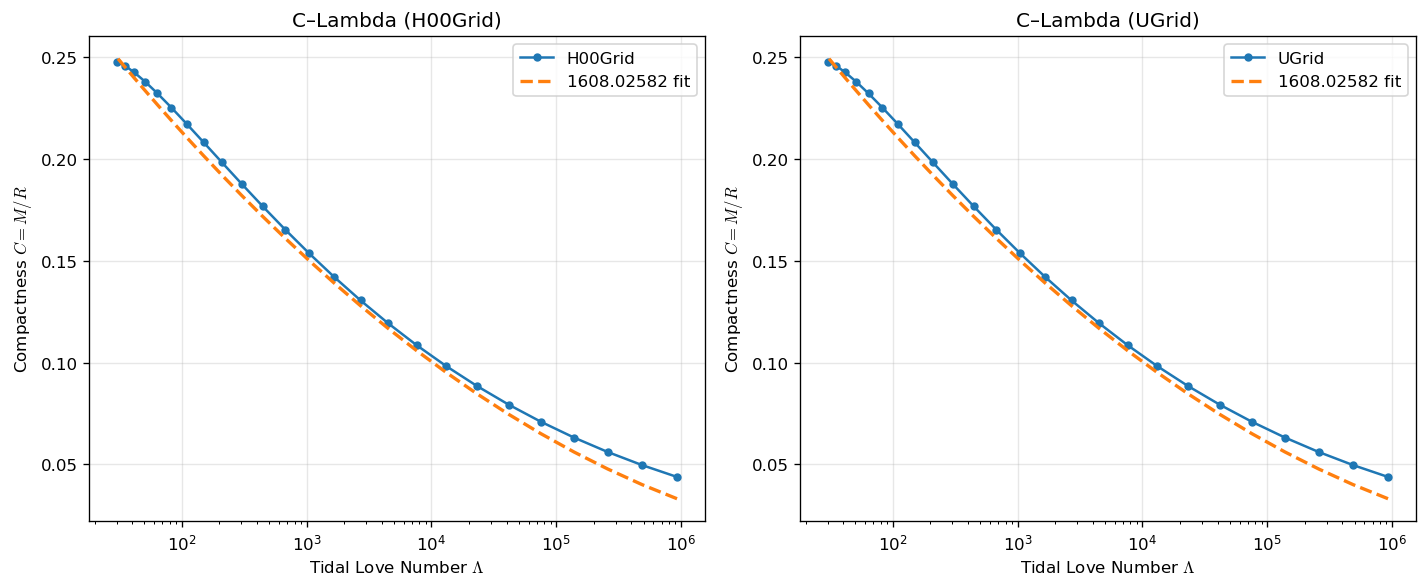

In [7]:
# Plot Love–C relation (1x2)
fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=120)

axes[0].plot(LoveArr, CompactnessArr, 'o-', label="H00Grid", markersize=4, linewidth=1.5)
axes[0].plot(LoveArr, CompactPRD(LoveArr), '--', label="1608.02582 fit", linewidth=2)
axes[0].set_xscale("log")
axes[0].set_xlabel(r"Tidal Love Number $\Lambda$")
axes[0].set_ylabel(r"Compactness $C = M/R$")
axes[0].set_title("C–Lambda (H00Grid)")
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

axes[1].plot(LoveArr_u, CompactnessArr, 'o-', label="UGrid", markersize=4, linewidth=1.5)
axes[1].plot(LoveArr_u, CompactPRD(LoveArr_u), '--', label="1608.02582 fit", linewidth=2)
axes[1].set_xscale("log")
axes[1].set_xlabel(r"Tidal Love Number $\Lambda$")
axes[1].set_ylabel(r"Compactness $C = M/R$")
axes[1].set_title("C–Lambda (UGrid)")
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


/var/folders/2w/8nb8998n2h38fndcsz3s5wq80000gn/T/ipykernel_62062/2505955583.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.97])


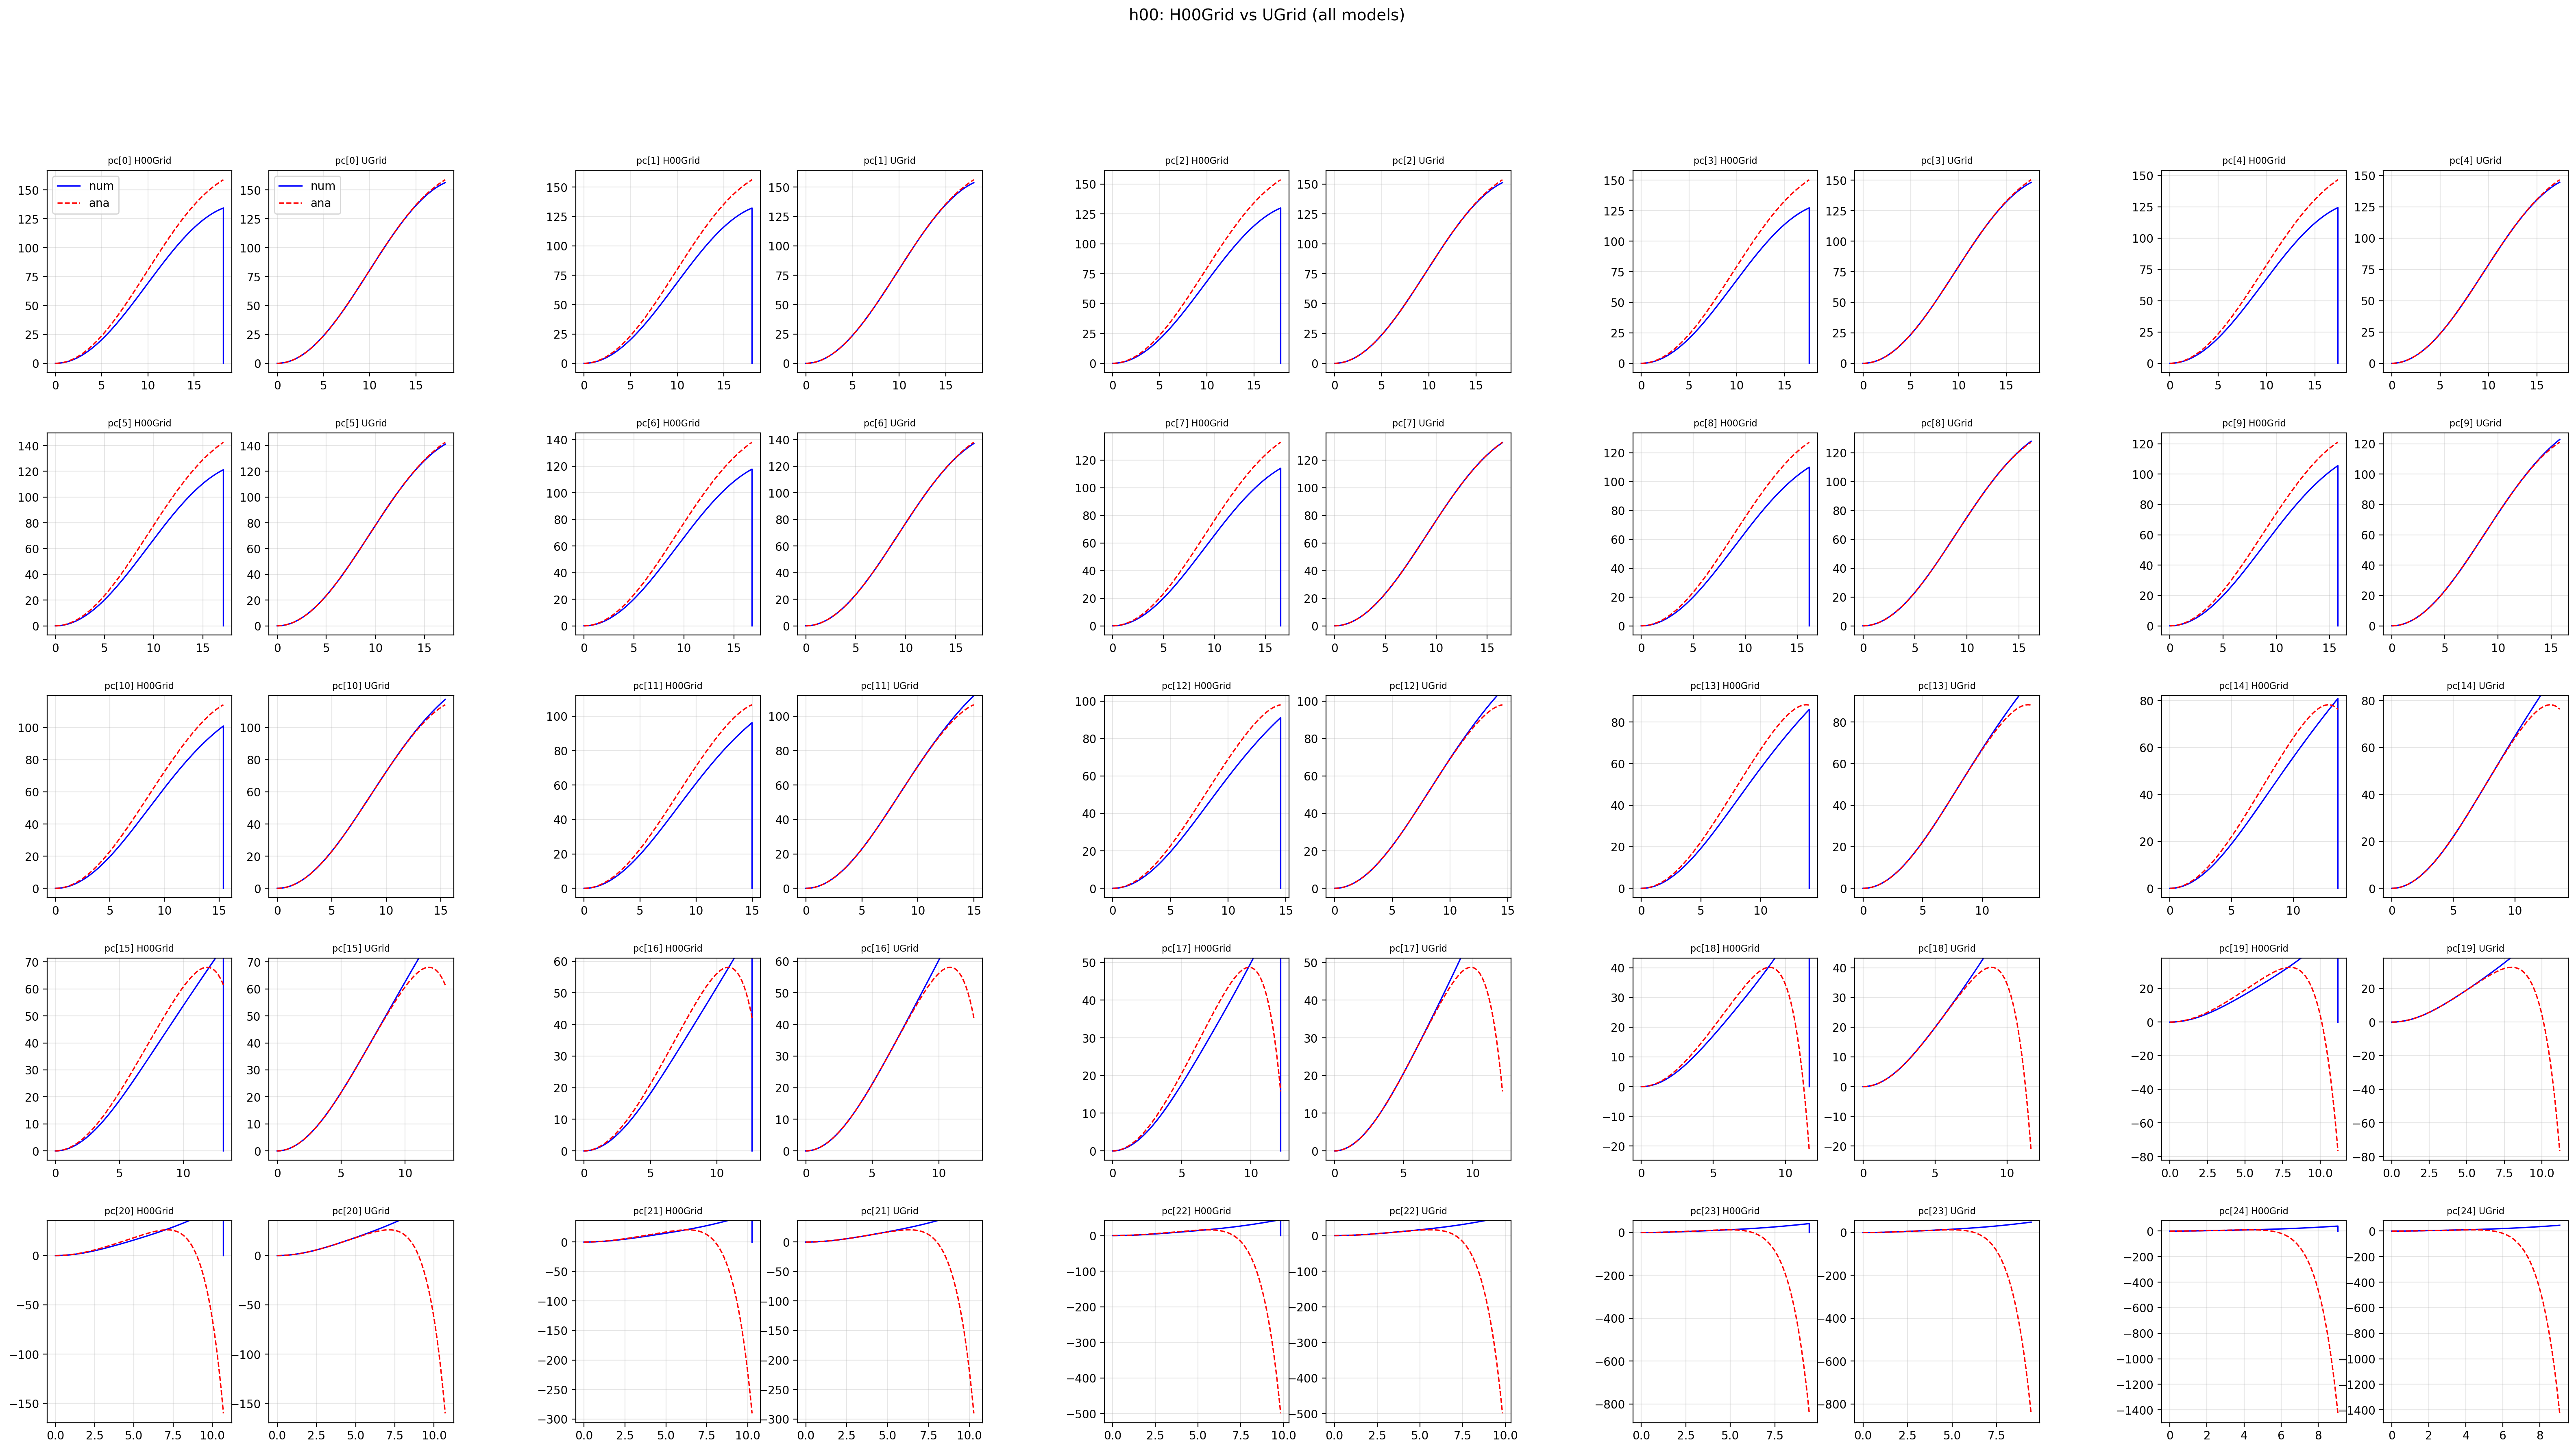

/var/folders/2w/8nb8998n2h38fndcsz3s5wq80000gn/T/ipykernel_62062/2505955583.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.97])


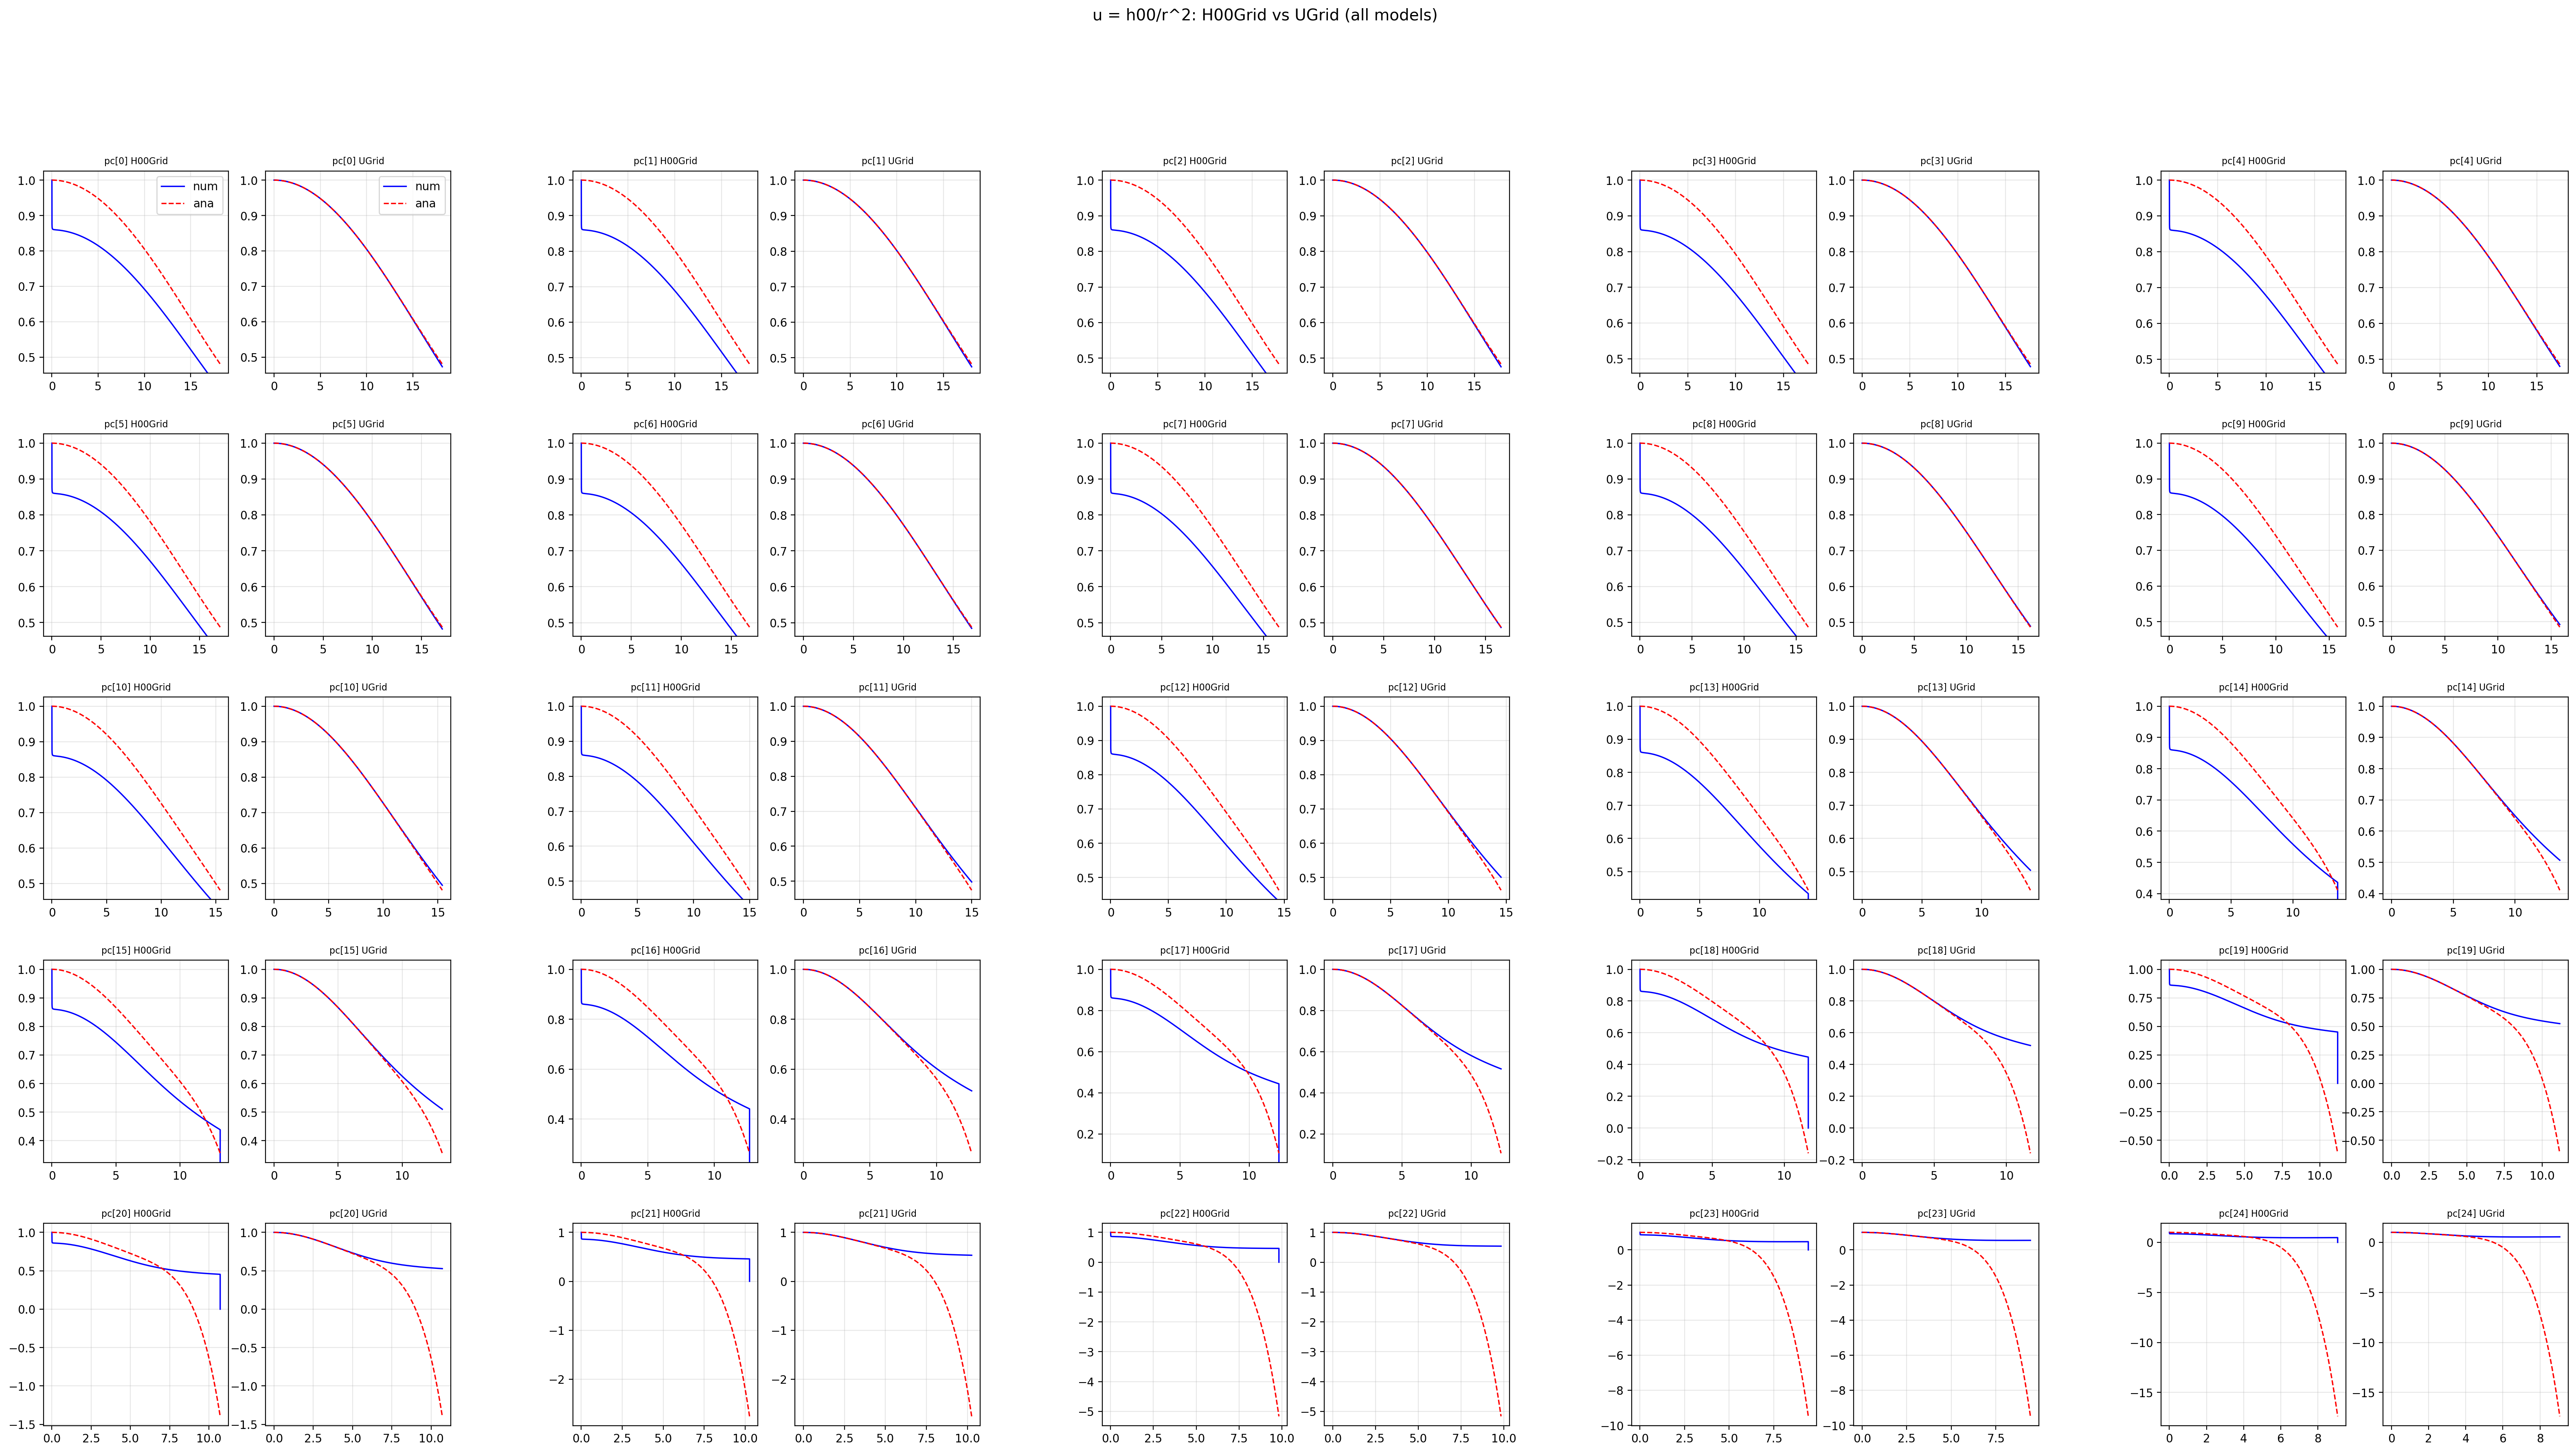

In [8]:
# Compare numerical vs analytic h00 and u for all models (5x5 grid, 1x2 subplots per model)
n_models = min(d_num, 25)
grid_n = 5

# h00 grids
fig = plt.figure(figsize=(40, 20), dpi=200)
outer = fig.add_gridspec(grid_n, grid_n, wspace=0.3, hspace=0.3)

for idx in range(n_models):
    i = idx // grid_n
    j = idx % grid_n
    sub = outer[i, j].subgridspec(1, 2, wspace=0.2)
    axL = fig.add_subplot(sub[0, 0])
    axR = fig.add_subplot(sub[0, 1])

    RArr = np.array(Rgrid[idx])
    r_h00 = RArr[:-1]
    pc = PcArr[idx]

    h00_num = H00Grid[idx][:, 0]
    h00_ana = h00_approx(r=r_h00, K=K_geom, pc=pc, a0=1, a8=0)

    # UGrid-based h00
    u_num_u = UGrid[idx][:len(r_h00), 0]
    h00_num_u = u_num_u * (r_h00**2)

    axL.plot(r_h00, h00_num, 'b-', linewidth=1.2, label='num')
    axL.plot(r_h00, h00_ana, 'r--', linewidth=1.2, label='ana')
    axL.set_title(f'pc[{idx}] H00Grid', fontsize=8)
    axL.grid(alpha=0.3)

    axR.plot(r_h00, h00_num_u, 'b-', linewidth=1.2, label='num')
    axR.plot(r_h00, h00_ana, 'r--', linewidth=1.2, label='ana')
    axR.set_title(f'pc[{idx}] UGrid', fontsize=8)
    axR.grid(alpha=0.3)

    for ax in [axL, axR]:
        scale = np.max(h00_ana) - np.min(h00_ana)
        ax.set_ylim(np.min(h00_ana) - scale * 0.05, np.max(h00_ana) + scale * 0.05)

    if idx == 0:
        axL.legend(fontsize=10)
        axR.legend(fontsize=10)

fig.suptitle('h00: H00Grid vs UGrid (all models)', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

# u = h00/r^2 grids
fig = plt.figure(figsize=(40, 20), dpi=200)
outer = fig.add_gridspec(grid_n, grid_n, wspace=0.3, hspace=0.3)

for idx in range(n_models):
    i = idx // grid_n
    j = idx % grid_n
    sub = outer[i, j].subgridspec(1, 2, wspace=0.2)
    axL = fig.add_subplot(sub[0, 0])
    axR = fig.add_subplot(sub[0, 1])

    RArr = np.array(Rgrid[idx])
    r_h00 = RArr[:-1]
    pc = PcArr[idx]

    h00_num = H00Grid[idx][:, 0]
    h00_ana = h00_approx(r=r_h00, K=K_geom, pc=pc, a0=1, a8=0)
    u_num = h00_num / (r_h00**2)
    u_ana = h00_ana / (r_h00**2)

    u_num_u = UGrid[idx][:len(r_h00), 0]

    axL.plot(r_h00, u_num, 'b-', linewidth=1.2, label='num')
    axL.plot(r_h00, u_ana, 'r--', linewidth=1.2, label='ana')
    # axL.set_yscale('log')
    axL.set_title(f'pc[{idx}] H00Grid', fontsize=8)
    axL.grid(alpha=0.3)

    axR.plot(r_h00, u_num_u, 'b-', linewidth=1.2, label='num')
    axR.plot(r_h00, u_ana, 'r--', linewidth=1.2, label='ana')
    # axR.set_yscale('log')
    axR.set_title(f'pc[{idx}] UGrid', fontsize=8)
    axR.grid(alpha=0.3)

    for ax in [axL, axR]:
        scale = np.max(u_ana) - np.min(u_ana)
        ax.set_ylim(np.min(u_ana) - scale * 0.05, np.max(u_ana) + scale * 0.05)

    if idx == 0:
        axL.legend(fontsize=10)
        axR.legend(fontsize=10)

fig.suptitle('u = h00/r^2: H00Grid vs UGrid (all models)', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()
